In [10]:
# ===== LIBRERÍAS =====
import time
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import StratifiedKFold, train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import gc


In [11]:
# ===== PLOT =====
def plot_cv_average_history_Cheb(histories_Cheb):
    max_epochs_Cheb = max([len(h.history['loss']) for h in histories_Cheb])
    epochs_Cheb = np.arange(1, max_epochs_Cheb + 1)

    def get_padded_metrics_Cheb(metric_name):
        matrix_Cheb = np.full((len(histories_Cheb), max_epochs_Cheb), np.nan)
        for i, h in enumerate(histories_Cheb):
            data_Cheb = h.history[metric_name]
            matrix_Cheb[i, :len(data_Cheb)] = data_Cheb
        return np.nanmean(matrix_Cheb, axis=0)

    avg_loss_Cheb = get_padded_metrics_Cheb('loss')
    avg_val_loss_Cheb = get_padded_metrics_Cheb('val_loss')
    avg_acc_Cheb = get_padded_metrics_Cheb('accuracy')
    avg_val_acc_Cheb = get_padded_metrics_Cheb('val_accuracy')

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_Cheb, avg_loss_Cheb)
    plt.plot(epochs_Cheb, avg_val_loss_Cheb)
    plt.title('Pérdida Promedio')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_Cheb, avg_acc_Cheb)
    plt.plot(epochs_Cheb, avg_val_acc_Cheb)
    plt.title('Precisión Promedio')

    plt.tight_layout()
    plt.show()


In [12]:
class ChebyshevLayer(layers.Layer):
    def __init__(self, units, degree, **kwargs):
        super(ChebyshevLayer, self).__init__(**kwargs)
        self.units = units
        self.degree = degree

    def build(self, input_shape):
        # Pesos para cada grado del polinomio
        self.w = self.add_weight(
            shape=(self.degree + 1, input_shape[-1], self.units),
            initializer="glorot_uniform",
            trainable=True,
            name="chebyshev_weights"
        )

    def call(self, inputs):
        # Valores iniciales de la recurrencia de Chebyshev
        # T0(x) = 1
        previous_previous_poly = tf.ones_like(inputs)

        # T1(x) = x
        previous_poly = inputs

        # Salida inicial con los dos primeros grados
        output_values = (
            tf.matmul(previous_previous_poly, self.w[0]) +
            tf.matmul(previous_poly, self.w[1])
        )

        # Aqui de forma recursiva generamos los otros grados 
        for degree_index in range(2, self.degree + 1):
            current_poly = 2.0 * inputs * previous_poly - previous_previous_poly

            output_values += tf.matmul(current_poly, self.w[degree_index])

            # Preparamos la siguiente iteración
            previous_previous_poly = previous_poly
            previous_poly = current_poly

        return output_values

In [13]:
def build_chebyshev_model(degree, input_dim, num_classes):
    inputs = keras.Input(shape=(input_dim,))

    x = ChebyshevLayer(64, degree=degree)(inputs)
    x = layers.Activation("swish")(x)
    x = layers.Dense(16, activation="swish")(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [14]:
# ===== DATOS =====
idDataset = 159
dataset = fetch_ucirepo(id=idDataset)

X = dataset.data.features.to_numpy()
y = dataset.data.targets.to_numpy()



# ===== HIPERPARÁMETROS =====
epochs_Cheb = 10
batch_size_Cheb = 32
input_dim_Cheb = X.shape[1]
num_classes = len(np.unique(y))
num_splits_Cheb = 10
degrees = [3, 5, 7]


In [15]:

def createEarlyStoppingCallback_Cheb(patience_Cheb=15):
    return keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=patience_Cheb,
        restore_best_weights=True
    )


In [16]:
skf = StratifiedKFold(n_splits=num_splits_Cheb, shuffle=True, random_state=1)

scores = {deg: [] for deg in degrees}
histories = {deg: [] for deg in degrees}
times = {deg: [] for deg in degrees}


# ===== CROSS VALIDATION =====
for train_idx, test_idx in skf.split(X, y):

    # Split
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Codificación multiclase
    le = LabelEncoder()
    y_train = le.fit_transform(y_train)
    y_test = le.transform(y_test)

    # Validación interna
    X_subtrain, X_val, y_subtrain, y_val = train_test_split(
        X_train,
        y_train,
        test_size=0.3,
        stratify=y_train,
        random_state=42
    )

    # Normalización
    scaler = MinMaxScaler(feature_range=(-1, 1))
    X_subtrain = scaler.fit_transform(X_subtrain)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    # Nº clases dinámico
    num_classes = len(np.unique(y_train))

    # Entrenamiento por grado
    for deg in degrees:
        tf.keras.backend.clear_session()

        model = build_chebyshev_model(deg, X_subtrain.shape[1], num_classes)

        start = time.time()

        history = model.fit(
            X_subtrain,
            y_subtrain,
            validation_data=(X_val, y_val),
            epochs=epochs_Cheb,
            batch_size=32,
            verbose=0,
            callbacks=[createEarlyStoppingCallback_Cheb()]
        )

        end = time.time()

        score = model.evaluate(X_test, y_test, verbose=0)

        histories[deg].append(history)
        scores[deg].append(score)
        times[deg].append(end - start)

        del model
        gc.collect()

d:\Programas\Anaconda\envs\Polynomial_Env\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
d:\Programas\Anaconda\envs\Polynomial_Env\Lib\site-packages\sklearn\preprocessing\_label.py:139: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
d:\Programas\Anaconda\envs\Polynomial_Env\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
d:\Programas\Anaconda\envs\Polynomial_Env\Lib\site-packages\sklearn\preprocessing\_label.py:139: DataConversionWarn


  RESULTADOS FINALES (Promedio CV - Chebyshev)
Grado 3: Pérdida Promedio = 0.3281, Precisión Promedio = 0.8642


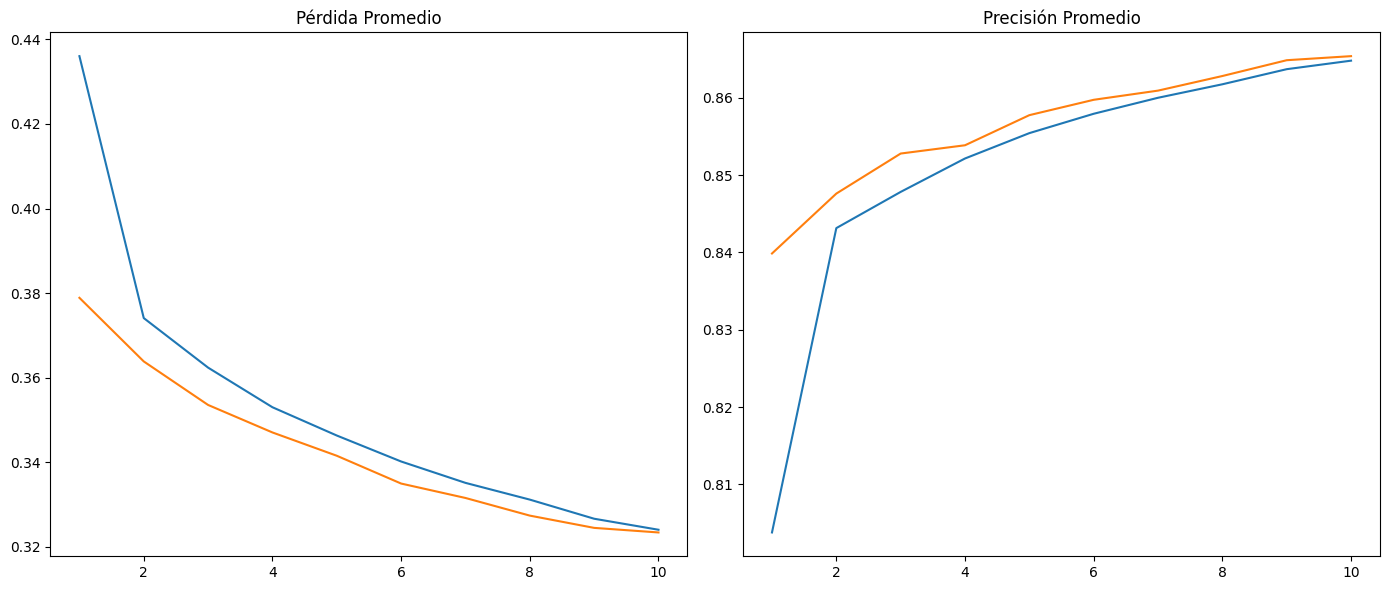

Grado 5: Pérdida Promedio = 0.3205, Precisión Promedio = 0.8705


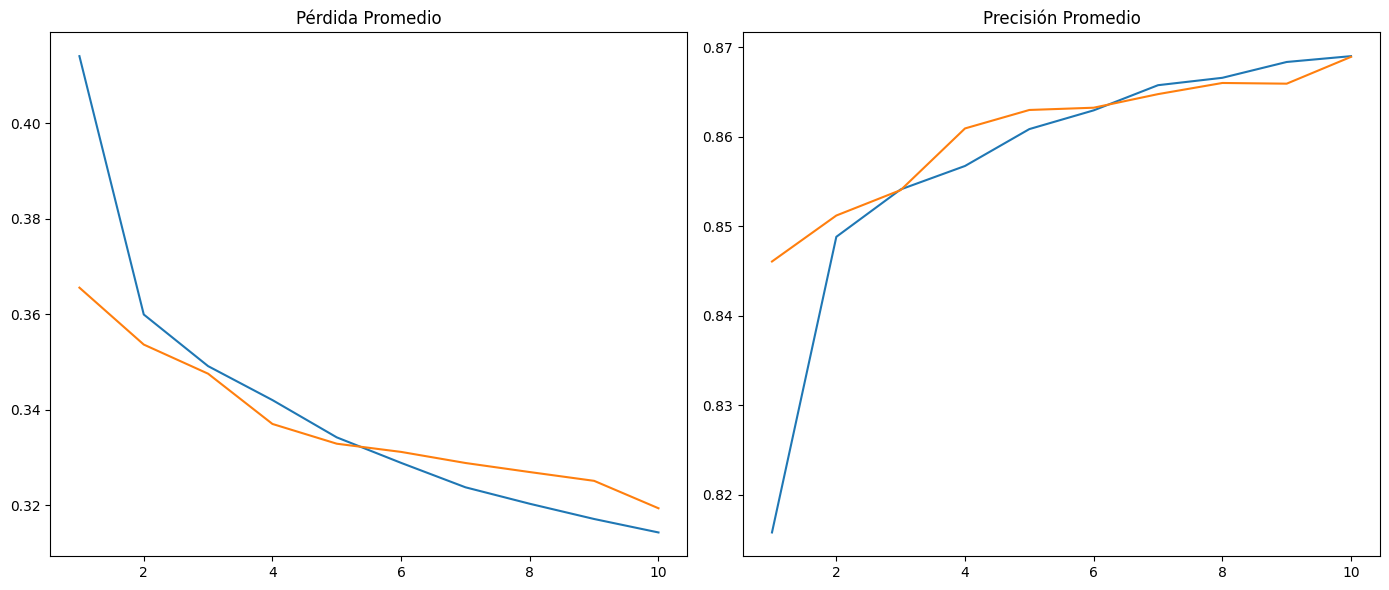

Grado 7: Pérdida Promedio = 0.3158, Precisión Promedio = 0.8683


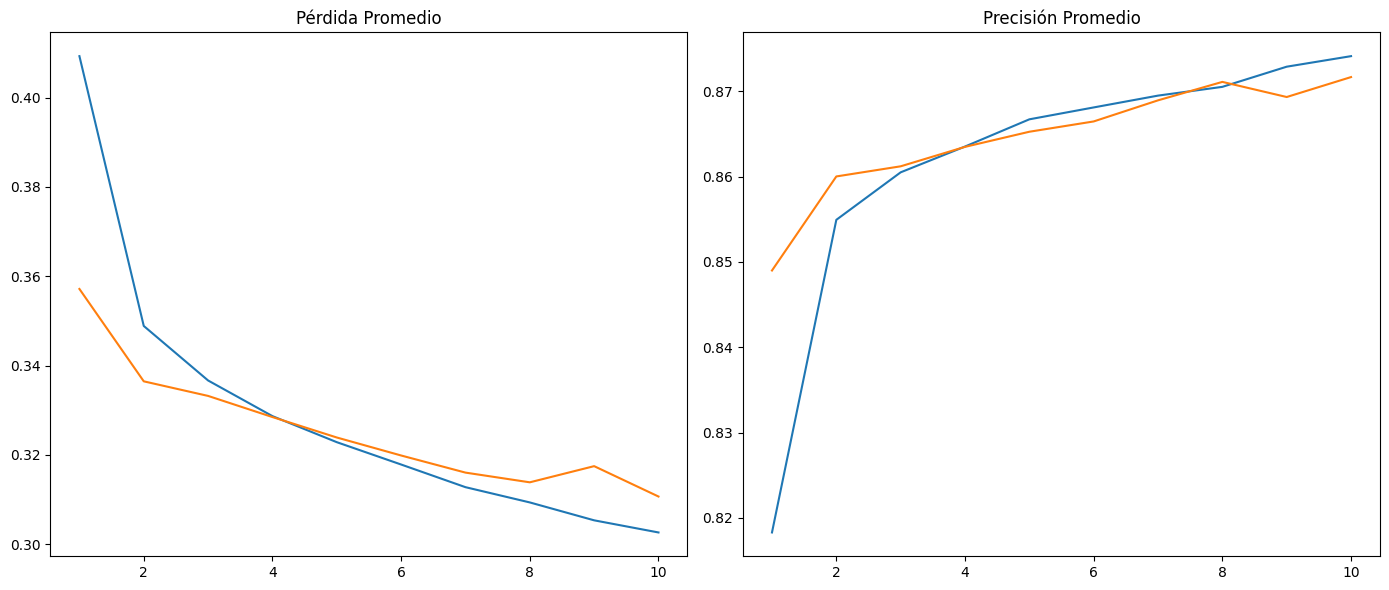

In [17]:

# ===== MÉTRICAS =====
def calculator(scores, times):
    loss = np.mean([s[0] for s in scores])
    acc = np.mean([s[1] for s in scores])
    t = np.mean(times)
    return loss, acc, t


print("\n" + "="*40)
print("  RESULTADOS FINALES (Promedio CV - Chebyshev)")
print("="*40)

scoreMean_Cheb = {}
for deg in degrees:
    scoreMean_Cheb[deg] = calculator(scores[deg], times[deg])
    print(f"Grado {deg}: Pérdida Promedio = {scoreMean_Cheb[deg][0]:.4f}, Precisión Promedio = {scoreMean_Cheb[deg][1]:.4f}")
    plot_cv_average_history_Cheb(histories[deg])


In [18]:
import pandas as pd
import os

def save_results_to_csv_Chebyshev(scoreMean_dict, degrees_list, filename="temp_res_chebyshev.csv"):
    """
    Guarda los resultados del modelo Chebyshev en ../resultados/
    """
    # 1. Definir la ruta de la carpeta (un nivel arriba '..', carpeta 'resultados')
    carpeta_destino = os.path.join("..", "resultados")
    
    # 2. Crear la ruta completa del archivo
    ruta_completa = os.path.join(carpeta_destino, filename)
    
    data = []
    
    # 3. Extraer los datos del diccionario scoreMean_Cheb que creaste en tu bucle
    for deg in degrees_list:
        avg_loss = scoreMean_dict[deg][0]
        avg_accuracy = scoreMean_dict[deg][1]
        
        data.append({
            "Polinomio": "Chebyshev",
            "Grado": deg,
            "Mejor_N": "N/A",  # Chebyshev no usa el parámetro N de Shmaliy
            "Loss_Promedio": round(avg_loss, 6),
            "Accuracy_Promedio": round(avg_accuracy, 6)
        })
        
    # 4. Crear DataFrame y guardar
    df_resultados = pd.DataFrame(data)
    df_resultados.to_csv(ruta_completa, index=False, sep=';')
    
    print(f"\n[INFO] Resultados de Chebyshev guardados en:\n ---> '{os.path.abspath(ruta_completa)}'")


In [19]:

# ===== LLAMADA A LA FUNCIÓN =====
# Pon esto al final de tu notebook, después de los prints de resultados
save_results_to_csv_Chebyshev(scoreMean_Cheb, degrees, filename="temp_res_chebyshev.csv")

OSError: Cannot save file into a non-existent directory: '..\resultados'